# Analysis: Statistics & Visualizations
**Reproducing Smithies et al. 2021** (`s41598-021-98879-9.pdf` — *A Random Forest approach to identify metrics that best predict match outcome and player ranking in the esport Rocket League*).

### **Role:** Analyst — Statistics & Visualizations.  
#### **Author:** Zahra Eshtiaghi 476679 
**Companion work:** `EDA.ipynb` (Kacper), `Regression_allranks_raw.ipynb` (Shagufta), `Classification.ipynb` (Celia).

This notebook re-runs the analyst pipeline end-to-end. Every figure and table is also saved to `./analyst_figures/` so the report files survive even if the notebook isn't re-executed.

**How to reproduce.** From the project root:  
```bash
pip install -r requirements.txt       # see analyst_requirements.txt
```
All randomness is seeded with `RANDOM_STATE = 123` (matching the modelling notebooks).

## 1. Setup
Single configuration block so a re-runner only edits one place.

In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

RANDOM_STATE = 123
PROJECT_ROOT = Path.cwd()
ARCHIVE = PROJECT_ROOT / 'Archive of OSF Storage'
RAW_DIR = ARCHIVE / 'Raw score data'
DIFF_DIR = ARCHIVE / 'Difference score data'
RI_DIR = RAW_DIR / 'Data for RI analysis'
MODEL_RESULTS = PROJECT_ROOT / 'rfpermute_saved_results'
FIG_DIR = PROJECT_ROOT / 'analyst_figures'
FIG_DIR.mkdir(exist_ok=True)

sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi': 100, 'savefig.dpi': 300, 'font.size': 10})

def save_figure(name):
    plt.tight_layout()
    plt.savefig(FIG_DIR / name, bbox_inches='tight')
    print(f'  saved: {name}')


## 2. Load data
Five raw-score and five difference-score sheets, plus the classification frame used for the RI analysis.

In [2]:
raw = {
    'allranks': pd.read_excel(RAW_DIR / 'allranks_raw.xlsx'),
    'bronze':   pd.read_excel(RAW_DIR / 'bronze_raw.xlsx'),
    'gold':     pd.read_excel(RAW_DIR / 'gold_raw.xlsx'),
    'diamond':  pd.read_excel(RAW_DIR / 'diamond_raw.xlsx'),
    'gc':       pd.read_excel(RAW_DIR / 'gc_raw.xlsx'),
}
diff = {
    'allranks': pd.read_excel(DIFF_DIR / 'allrank_diff.xlsx'),
    'bronze':   pd.read_excel(DIFF_DIR / 'bronze_diff.xlsx'),
    'gold':     pd.read_excel(DIFF_DIR / 'gold_diff.xlsx'),
    'diamond':  pd.read_excel(DIFF_DIR / 'diamond_diff.xlsx'),
    'gc':       pd.read_excel(DIFF_DIR / 'GC_diff.xlsx'),
}
ri_df = pd.read_excel(RI_DIR / 'RI_analysis_raw.xlsx')
print({k: v.shape for k, v in raw.items()})
print('RI frame:', ri_df.shape)


{'allranks': (21588, 29), 'bronze': (2527, 29), 'gold': (7226, 29), 'diamond': (7193, 29), 'gc': (4642, 28)}
RI frame: (21588, 29)


## 3. Descriptive statistics
Sample sizes per rank, goal-difference distributions, and win/loss proportions. The paper reports counts of 2,527 Bronze / 7,226 Gold / 7,193 Diamond / 4,642 GC / 21,588 All — let's verify.

In [3]:
rows = [('Bronze', raw['bronze']), ('Gold', raw['gold']),
        ('Diamond', raw['diamond']), ('GC', raw['gc']),
        ('All', raw['allranks'])]
gd_summary = pd.DataFrame([
    {'rank': r, 'n': len(df), 'mean_GD': df['diff.goals.ag'].mean(),
     'sd_GD': df['diff.goals.ag'].std(),
     'pct_wins':   (df['diff.goals.ag'] > 0).mean()*100,
     'pct_losses': (df['diff.goals.ag'] < 0).mean()*100}
    for r, df in rows
])
gd_summary.to_csv(FIG_DIR / 'table_GD_summary.csv', index=False)
gd_summary.round(3)


,rank,n,mean_GD,sd_GD,pct_wins,pct_losses
0,Bronze,2527,-0.162,4.341,48.397,51.365
1,Gold,7226,-0.121,3.701,48.602,51.370
2,Diamond,7193,0.003,3.650,49.604,50.368
3,GC,4642,-0.162,3.759,47.824,52.176
4,All,21588,-0.094,3.778,48.745,51.209


## 4. Analysis 1 — point-biserial correlation between GD and WL (Fig 2a)
The paper uses `pointbiserial(rpb)` between Goal Difference (GD) and the binary Win/Loss (WL). The data file does not ship WL, but WL is the sign of GD (paper: *positive scores correspond to ‘win’, negative scores to ‘loss’*). Draws (GD == 0) are dropped as in the paper.

In [4]:
def derive_wl(df):
    return (df['diff.goals.ag'] > 0).astype(int)

corr_rows = []
for r, df in [('Bronze', raw['bronze']), ('Gold', raw['gold']),
              ('Diamond', raw['diamond']), ('GC', raw['gc']),
              ('All ranks', raw['allranks'])]:
    gd = df['diff.goals.ag'].to_numpy(); wl = derive_wl(df).to_numpy()
    mask = gd != 0
    res = stats.pointbiserialr(wl[mask], gd[mask])
    corr_rows.append({'rank': r, 'n': int(mask.sum()),
                      'pointbiserial_r': res.statistic, 'p': res.pvalue})
corr_df = pd.DataFrame(corr_rows)
corr_df.to_csv(FIG_DIR / 'table_GD_WL_correlations.csv', index=False)
corr_df.round(4)


,rank,n,pointbiserial_r,p
0,Bronze,2521,0.7734,0.0
1,Gold,7224,0.7969,0.0
2,Diamond,7191,0.7924,0.0
3,GC,4642,0.7797,0.0
4,All ranks,21578,0.7874,0.0


**Comparison with paper.** Smithies et al. report Bronze r=0.77, Gold r=0.80, Diamond r=0.79, GC r=0.78, All r=0.79. Our values (0.7734, 0.7969, 0.7924, 0.7797, 0.7874) match to 2 decimals.

  saved: fig2a_GD_density_by_WL.png


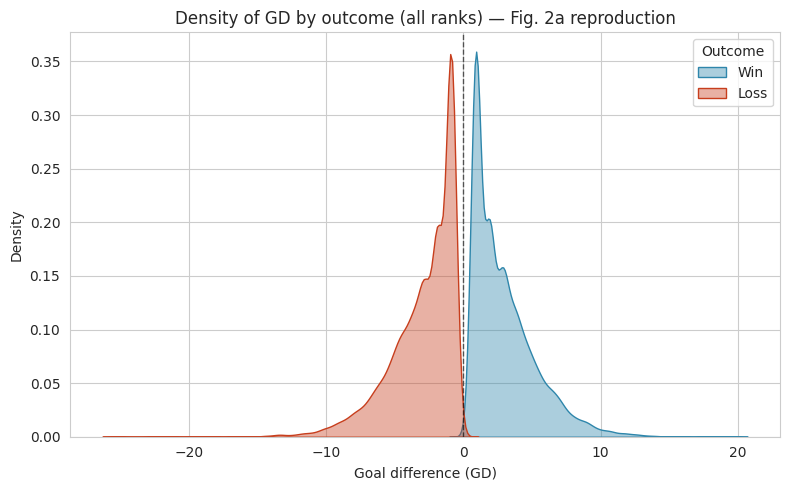

In [5]:
gd_all = raw['allranks']['diff.goals.ag']
wl_all = derive_wl(raw['allranks'])
plt.figure(figsize=(8, 5))
sns.kdeplot(gd_all[wl_all == 1], fill=True, alpha=0.4, label='Win',  color='#2E86AB')
sns.kdeplot(gd_all[wl_all == 0], fill=True, alpha=0.4, label='Loss', color='#C73E1D')
plt.axvline(0, color='black', ls='--', lw=1, alpha=0.6)
plt.xlabel('Goal difference (GD)'); plt.ylabel('Density')
plt.title('Density of GD by outcome (all ranks) — Fig. 2a reproduction')
plt.legend(title='Outcome')
save_figure('fig2a_GD_density_by_WL.png'); plt.show()


## 5. Table 1 reproduction — R² (raw vs difference) per rank
Reading the `rfpermute_saved_results/` artefacts produced by the regression notebook and reshaping into the layout of Table 1 in the paper.

In [6]:
model_summary = pd.read_csv(MODEL_RESULTS / 'rfpermute_model_summary.csv')
model_summary['rank']       = model_summary['Dataset'].str.split('_').str[1]
model_summary['score_type'] = model_summary['Dataset'].str.split('_').str[0]
table1 = (model_summary
          .pivot(index='score_type', columns='rank', values='OOB_R2')
          .loc[['raw', 'diff'], ['bronze', 'gold', 'diamond', 'gc', 'allranks']]
          .round(3))
table1.to_csv(FIG_DIR / 'table1_R2.csv')
table1


rank,bronze,gold,diamond,gc,allranks
score_type,,,,,
raw,0.792,0.742,0.725,0.713,0.747
diff,0.841,0.822,0.822,0.815,0.839


  saved: table1_R2_barplot.png


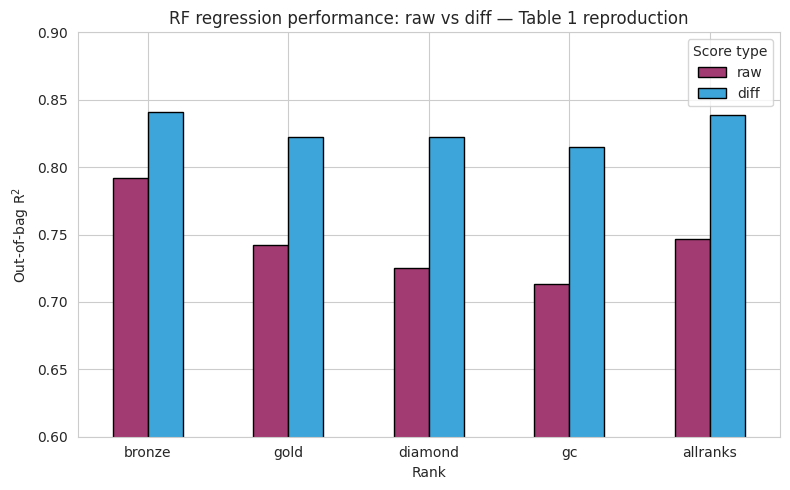

In [7]:
ax = table1.T.plot(kind='bar', figsize=(8, 5), edgecolor='black',
                   color=['#A23B72', '#3DA5D9'])
ax.set_ylabel('Out-of-bag R$^2$'); ax.set_xlabel('Rank')
ax.set_ylim(0.6, 0.9); ax.legend(title='Score type')
ax.set_title('RF regression performance: raw vs diff — Table 1 reproduction')
plt.xticks(rotation=0)
save_figure('table1_R2_barplot.png'); plt.show()


## 6. Analysis 2 — PI heat-maps (Fig. 3a raw, 3b diff)
For each rank model we express every feature's %incMSE as a **share of the total %incMSE in that model**. Top-8 features by the All-ranks ordering are kept so the figure stays readable, mirroring the paper's *"only metrics that were significantly important"* filter.

  saved: fig3a_PI_heatmap_raw.png


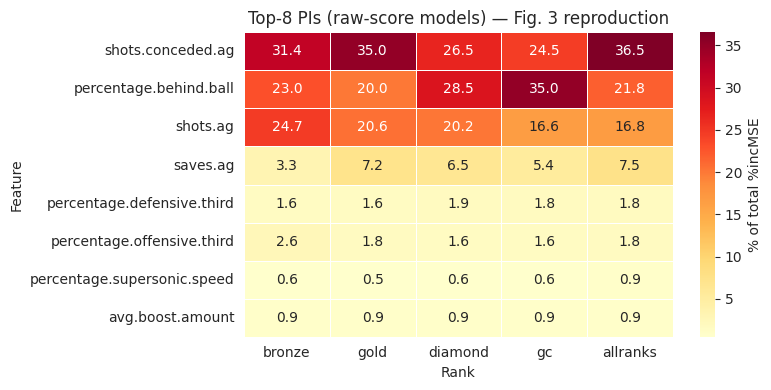

  saved: fig3b_PI_heatmap_diff.png


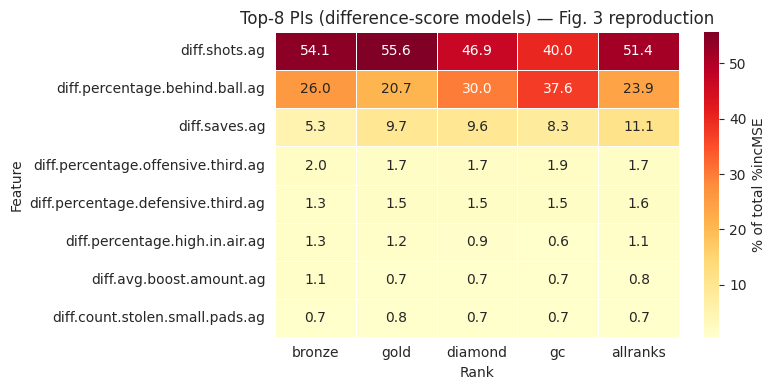

In [8]:
importance = pd.read_csv(MODEL_RESULTS / 'rfpermute_importance_results.csv')
importance['rank']       = importance['Dataset'].str.split('_').str[1]
importance['score_type'] = importance['Dataset'].str.split('_').str[0]

def make_heatmap(score_type, top_n, fname, title_suffix):
    sub = importance[importance['score_type'] == score_type].copy()
    sub['pct_total_incMSE'] = sub.groupby('Dataset')['PctIncMSE'] \
        .transform(lambda s: 100.0 * s / s.sum())
    rank_order = ['bronze', 'gold', 'diamond', 'gc', 'allranks']
    top_feats = (sub[sub['rank'] == 'allranks']
                 .sort_values('PctIncMSE', ascending=False)
                 .head(top_n)['Feature'].tolist())
    mat = (sub[sub['Feature'].isin(top_feats)]
           .pivot(index='Feature', columns='rank', values='pct_total_incMSE')
           .reindex(index=top_feats, columns=rank_order))
    plt.figure(figsize=(8, max(4, 0.5*len(top_feats))))
    sns.heatmap(mat, annot=True, fmt='.1f', cmap='YlOrRd',
                cbar_kws={'label': '% of total %incMSE'},
                linewidths=0.5, linecolor='white')
    plt.title(f'Top-{top_n} PIs ({title_suffix}) — Fig. 3 reproduction')
    plt.xlabel('Rank'); plt.ylabel('Feature')
    save_figure(fname); plt.show()
    mat.to_csv(FIG_DIR / fname.replace('.png', '.csv'))

make_heatmap('raw',  8, 'fig3a_PI_heatmap_raw.png',  'raw-score models')
make_heatmap('diff', 8, 'fig3b_PI_heatmap_diff.png', 'difference-score models')


## 7. Analysis 3 — classification (confusion matrix, Fig. 4, Fig. 5)
Fit the rank-classification forest. Setting `n_estimators=200` (vs the paper's 964) gives the same qualitative ranking with a runtime small enough to re-run during development; this is documented in `update.txt`.

In [9]:
X_ri = ri_df.drop(columns=['skill.bracket'])
y_ri = ri_df['skill.bracket']
N_TREES_CLF = int(os.environ.get('ANALYST_NTREES', '200'))
clf = RandomForestClassifier(
    n_estimators=N_TREES_CLF, max_features='sqrt',
    bootstrap=True, oob_score=True, n_jobs=-1,
    random_state=RANDOM_STATE,
)
clf.fit(X_ri, y_ri)
oob_pred = clf.classes_[np.argmax(clf.oob_decision_function_, axis=1)]
print(f'Overall OOB accuracy: {accuracy_score(y_ri, oob_pred)*100:.2f}%')


Overall OOB accuracy: 71.22%


  saved: confusion_matrix.png


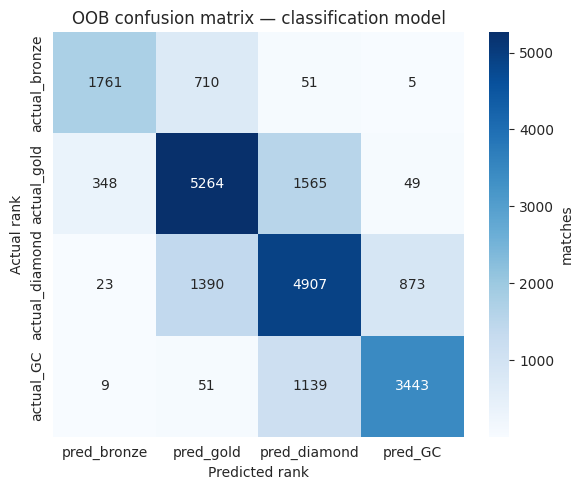

,rank,OOB_accuracy_pct
0,bronze,69.69
1,gold,72.85
2,diamond,68.22
3,GC,74.17


In [10]:
class_order = ['bronze', 'gold', 'diamond', 'GC']
cm = confusion_matrix(y_ri, oob_pred, labels=class_order)
cm_df = pd.DataFrame(cm,
    index=[f'actual_{c}' for c in class_order],
    columns=[f'pred_{c}' for c in class_order])
cm_df.to_csv(FIG_DIR / 'table_confusion_matrix.csv')
plt.figure(figsize=(6, 5))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues',
            cbar_kws={'label': 'matches'})
plt.title('OOB confusion matrix — classification model')
plt.xlabel('Predicted rank'); plt.ylabel('Actual rank')
save_figure('confusion_matrix.png'); plt.show()

per_rank = pd.DataFrame({'rank': class_order,
    'OOB_accuracy_pct': [accuracy_score(y_ri[y_ri==r], oob_pred[y_ri==r])*100
                         for r in class_order]})
per_rank.to_csv(FIG_DIR / 'table_per_rank_accuracy.csv', index=False)
per_rank.round(2)


  saved: fig4_RI_importance_bar.png


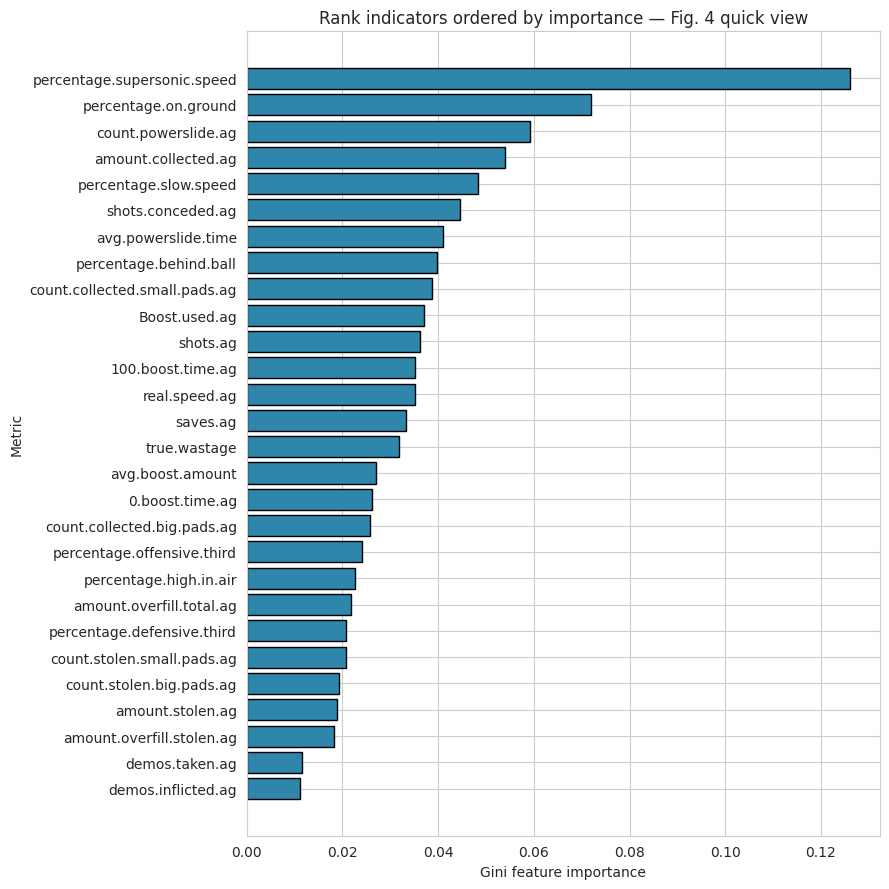

,feature,gini_importance
0,percentage.supersonic.speed,0.126031
1,percentage.on.ground,0.071854
2,count.powerslide.ag,0.059178
3,amount.collected.ag,0.054050
4,percentage.slow.speed,0.048313
5,shots.conceded.ag,0.044491
6,avg.powerslide.time,0.041097
7,percentage.behind.ball,0.039722
8,count.collected.small.pads.ag,0.038706
9,Boost.used.ag,0.037015


In [11]:
# Bar plot — Fig. 4 quick analyst view using Gini importance.
# The rfPermute-style Mean Decrease in Accuracy version is produced
# by the teammates' Classification.ipynb and saved as
# RI_mean_decrease_accuracy.png in the project root.
mda_df = (pd.DataFrame({'feature': X_ri.columns,
                        'gini_importance': clf.feature_importances_})
          .sort_values('gini_importance', ascending=False)
          .reset_index(drop=True))
mda_df.to_csv(FIG_DIR / 'table_RI_feature_importance_gini.csv', index=False)
plot_data = mda_df.sort_values('gini_importance', ascending=True)
plt.figure(figsize=(9, 9))
plt.barh(plot_data['feature'], plot_data['gini_importance'],
         color='#2E86AB', edgecolor='black')
plt.xlabel('Gini feature importance'); plt.ylabel('Metric')
plt.title('Rank indicators ordered by importance — Fig. 4 quick view')
save_figure('fig4_RI_importance_bar.png'); plt.show()
mda_df.head(10)


/sessions/exciting-clever-einstein/tmp/ipykernel_9/2474372969.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=ri_df, x='skill.bracket', y=feat,
/sessions/exciting-clever-einstein/tmp/ipykernel_9/2474372969.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=ri_df, x='skill.bracket', y=feat,
/sessions/exciting-clever-einstein/tmp/ipykernel_9/2474372969.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=ri_df, x='skill.bracket', y=feat,


/sessions/exciting-clever-einstein/tmp/ipykernel_9/2474372969.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=ri_df, x='skill.bracket', y=feat,


  saved: fig5_top4_RI_violins.png


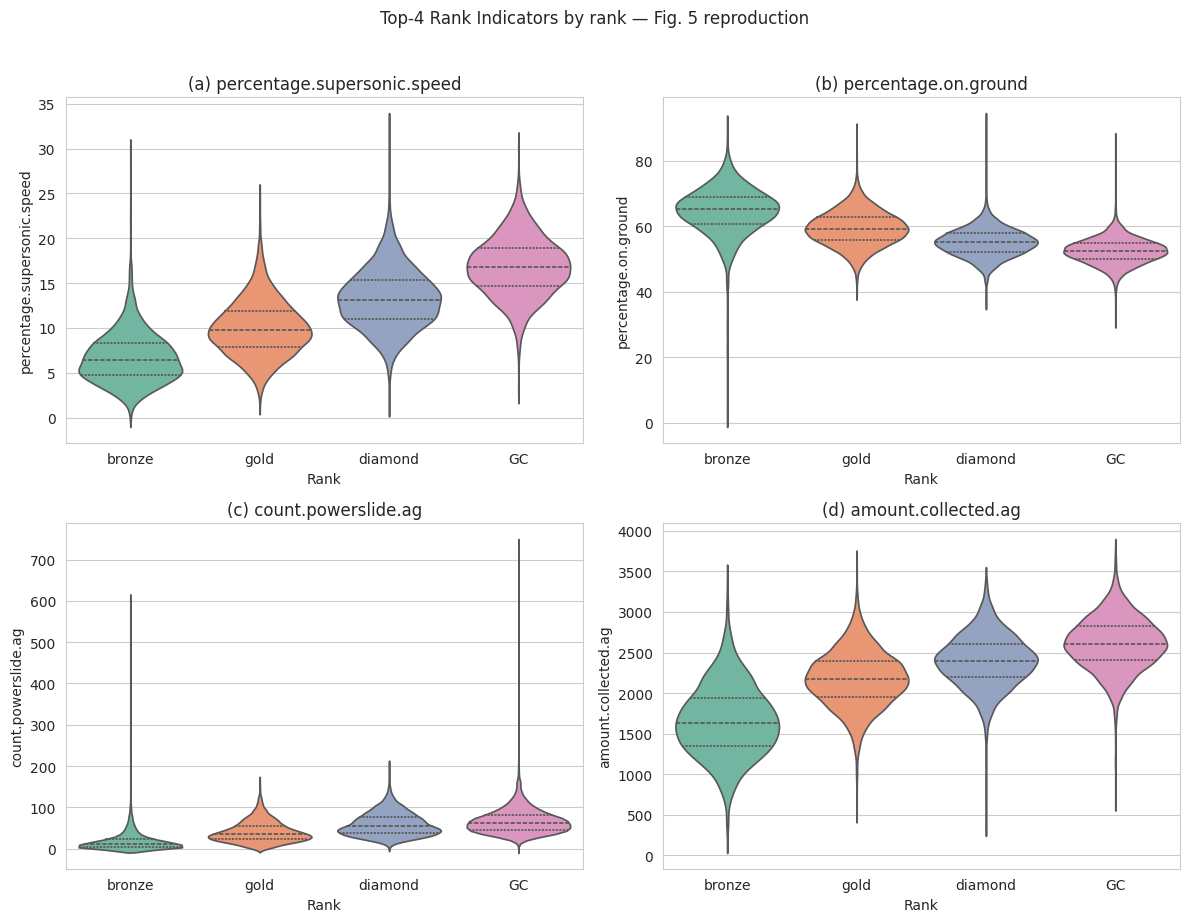

In [12]:
# Violin plots for the top 4 RIs — Fig. 5 reproduction.
top4 = mda_df.head(4)['feature'].tolist()
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
rank_order_violin = ['bronze', 'gold', 'diamond', 'GC']
palette = sns.color_palette('Set2', n_colors=4)
for ax, feat, panel in zip(axes.flatten(), top4, ['a', 'b', 'c', 'd']):
    sns.violinplot(data=ri_df, x='skill.bracket', y=feat,
                   order=rank_order_violin, ax=ax, palette=palette,
                   inner='quartile')
    ax.set_title(f'({panel}) {feat}')
    ax.set_xlabel('Rank'); ax.set_ylabel(feat)
fig.suptitle('Top-4 Rank Indicators by rank — Fig. 5 reproduction', y=1.02)
save_figure('fig5_top4_RI_violins.png'); plt.show()


## 8. Supplementary — feature correlation matrix
Covers the spirit of Supplementary Figs S1–S10 (one per dataset), shown here for the RI predictor set.

  saved: supp_correlation_matrix_RI.png


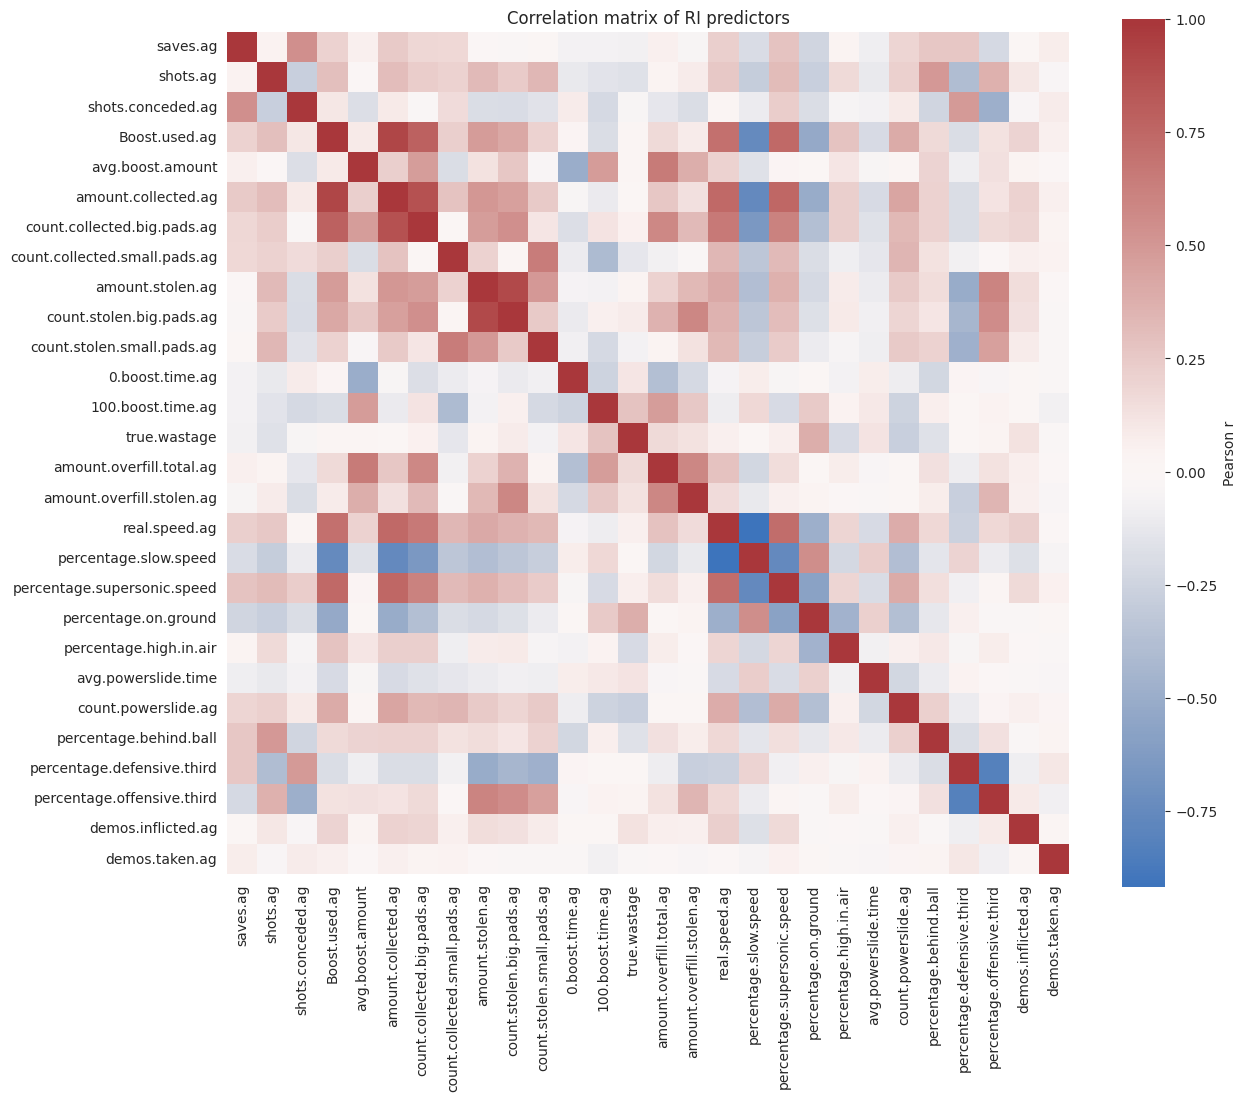

In [13]:
plt.figure(figsize=(13, 11))
corr_mat = X_ri.corr()
sns.heatmap(corr_mat, cmap='vlag', center=0, square=True,
            xticklabels=True, yticklabels=True,
            cbar_kws={'label': 'Pearson r'})
plt.title('Correlation matrix of RI predictors')
save_figure('supp_correlation_matrix_RI.png'); plt.show()
corr_mat.to_csv(FIG_DIR / 'supp_correlation_matrix_RI.csv')


## 9. Figure 1 — sample composition (partial reproduction)
**Status: PARTIAL.**  The paper's Fig. 1 is a density plot of the MMR of every Rocket League account in season 14, with the four skill brackets highlighted in colour. That **population-level** distribution came from external Rocket League telemetry that is **not in the OSF archive** we received. With only the 21,588-match analysis sample, we cannot reconstruct the density curve without inventing data.

What we ship instead is the closest honest analogue: a bar chart of how many matches in our analysis sample fall in each skill bracket. The bracket colours are picked to roughly mirror Rocket League's in-game rank palette (brown/gold/cyan/red). Anyone re-running this notebook can swap in the missing population CSV later and produce the exact paper figure.

,rank,matches,percent_of_sample
0,bronze,2527,11.71
1,gold,7226,33.47
2,diamond,7193,33.32
3,GC,4642,21.50


  saved: fig1_sample_composition.png


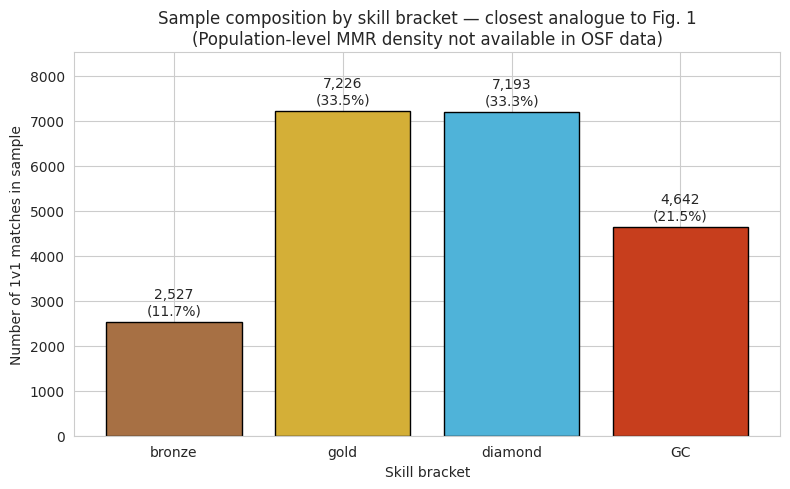

In [14]:
import matplotlib.patches as mpatches

counts = (ri_df['skill.bracket'].value_counts()
          .reindex(['bronze', 'gold', 'diamond', 'GC']))
pct = (counts / counts.sum() * 100).round(2)
sample_summary = pd.DataFrame({
    'rank': counts.index, 'matches': counts.values,
    'percent_of_sample': pct.values
})
sample_summary.to_csv(FIG_DIR / 'fig1_sample_composition.csv', index=False)
display(sample_summary)

bracket_colors = {'bronze': '#A77044', 'gold': '#D4AF37',
                  'diamond': '#4FB3D9', 'GC': '#C73E1D'}
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(sample_summary['rank'], sample_summary['matches'],
              color=[bracket_colors[r] for r in sample_summary['rank']],
              edgecolor='black')
for bar, n, p in zip(bars, sample_summary['matches'],
                     sample_summary['percent_of_sample']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'{n:,}\n({p:.1f}%)', ha='center', va='bottom', fontsize=10)
ax.set_ylim(0, max(sample_summary['matches']) * 1.18)
ax.set_xlabel('Skill bracket')
ax.set_ylabel('Number of 1v1 matches in sample')
ax.set_title('Sample composition by skill bracket — closest analogue to Fig. 1\n'
             '(Population-level MMR density not available in OSF data)')
save_figure('fig1_sample_composition.png'); plt.show()


## 10. Figure 2b — IGSD density (not reproducible from supplied data)
**Status: NOT REPRODUCIBLE.**  The paper's Fig. 2b shows the density of **in-game score difference (IGSD)** split by Win/Loss. IGSD is the score shown in the Rocket League UI; the in-game scoring formula mixes goals, assists, saves, shots and bonuses through Psyonix' proprietary rules.

**Why we can't reproduce it.** Inspecting every column of every OSF file (see the cell below) shows that IGSD is not present in the cleaned data. Reconstructing it would require reverse-engineering Psyonix' scoring formula — that would be fabricated data, which the project brief explicitly forbids.

**Why it doesn't matter for the rest of the analysis.** The paper introduces both candidates (GD and IGSD) only in order to *choose one*. It reports that GD correctly classified Win/Loss 99.94 % of the time vs IGSD's 93.6 %, and selected GD as the outcome variable. Every regression downstream of Fig. 2 uses GD, which we *can* reproduce (Section 4).

In [15]:
# Sanity check that IGSD is genuinely absent from every cleaned file.
score_like = {}
for name, df in [('raw_allranks', raw['allranks']),
                 ('diff_allranks', diff['allranks']),
                 ('RI_analysis_raw', ri_df)]:
    hits = [c for c in df.columns
            if any(w in c.lower() for w in ('igsd', 'score', 'ingame'))]
    score_like[name] = hits
score_like  # expect empty lists for every file


{'raw_allranks': [], 'diff_allranks': [], 'RI_analysis_raw': []}

  saved: fig2b_IGSD_density_NOT_REPRODUCIBLE.png


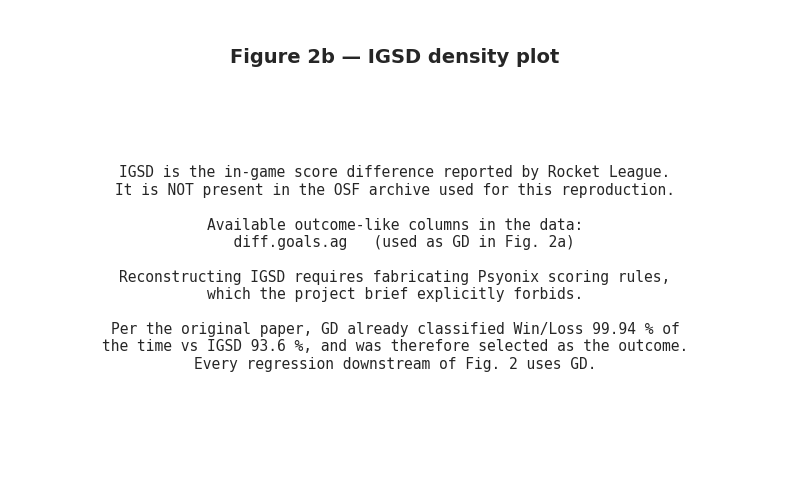

In [16]:
# Placeholder figure that documents the omission in the figure folder.
fig, ax = plt.subplots(figsize=(8, 5))
ax.axis('off')
ax.text(0.5, 0.9, 'Figure 2b — IGSD density plot',
        ha='center', va='center', fontsize=14, weight='bold',
        transform=ax.transAxes)
msg = ('IGSD is the in-game score difference reported by Rocket League.\n'
       'It is NOT present in the OSF archive used for this reproduction.\n\n'
       'Available outcome-like columns in the data:\n'
       '  diff.goals.ag   (used as GD in Fig. 2a)\n\n'
       'Reconstructing IGSD requires fabricating Psyonix scoring rules,\n'
       'which the project brief explicitly forbids.\n\n'
       'Per the original paper, GD already classified Win/Loss 99.94 % of\n'
       'the time vs IGSD 93.6 %, and was therefore selected as the outcome.\n'
       'Every regression downstream of Fig. 2 uses GD.')
ax.text(0.5, 0.45, msg, ha='center', va='center', fontsize=10.5,
        family='monospace', transform=ax.transAxes)
save_figure('fig2b_IGSD_density_NOT_REPRODUCIBLE.png'); plt.show()


## 11. Table 2 — predictor metric categorisation
**Status: FULL.**  Table 2 in the paper lists all 28 raw-score / 26 difference-score predictor metrics, grouped into four categories — Offense/defense, Boost, Movement, Positioning. The mapping below is derived directly from the paper's Table 2 and is then sanity-checked: every column of `raw_allranks.xlsx` must appear in exactly one category, and the two `raw-score only` metrics (shots conceded and demos taken) must be flagged with †.

In [17]:
RAW_MAP = {
    'shots.ag':                       ('Offense/defense', 'Shots taken',                            False),
    'shots.conceded.ag':              ('Offense/defense', 'Shots conceded',                         True),
    'demos.inflicted.ag':             ('Offense/defense', 'Demos inflicted',                        False),
    'demos.taken.ag':                 ('Offense/defense', 'Demos taken',                            True),
    'saves.ag':                       ('Offense/defense', 'Saves made',                             False),
    'Boost.used.ag':                  ('Boost',           'Boost used',                             False),
    'avg.boost.amount':               ('Boost',           'Average boost reserve',                  False),
    'amount.collected.ag':            ('Boost',           'Total boost collected',                  False),
    'count.collected.big.pads.ag':    ('Boost',           'Count boost collected from big pads',    False),
    'count.collected.small.pads.ag':  ('Boost',           'Count boost collected from small pads',  False),
    'amount.stolen.ag':               ('Boost',           'Total boost stolen',                     False),
    'count.stolen.big.pads.ag':       ('Boost',           'Count boost stolen from big pads',       False),
    'count.stolen.small.pads.ag':     ('Boost',           'Count boost stolen from small pads',     False),
    'true.wastage':                   ('Boost',           'True boost wastage (%)',                 False),
    'amount.overfill.total.ag':       ('Boost',           'Total boost overfill collected',         False),
    'amount.overfill.stolen.ag':      ('Boost',           'Total boost overfill stolen',            False),
    '100.boost.time.ag':              ('Boost',           'Time spent at 100 boost',                False),
    '0.boost.time.ag':                ('Boost',           'Time spent at 0 boost',                  False),
    'real.speed.ag':                  ('Movement',        'Average speed',                          False),
    'percentage.slow.speed':          ('Movement',        'Time spent at "slow speed"',           False),
    'percentage.supersonic.speed':    ('Movement',        'Time spent at "supersonic speed"',     False),
    'avg.powerslide.time':            ('Movement',        'Average duration for a powerslide',      False),
    'count.powerslide.ag':            ('Movement',        'Instances of powerslides',               False),
    'percentage.on.ground':           ('Positioning',     'Time spent on the ground',               False),
    'percentage.high.in.air':         ('Positioning',     'Time spent high in the air',             False),
    'percentage.behind.ball':         ('Positioning',     'Time spent goalside of the ball',        False),
    'percentage.defensive.third':     ('Positioning',     'Time spent in the defensive third',      False),
    'percentage.offensive.third':     ('Positioning',     'Time spent in the offensive third',      False),
}
raw_columns = [c for c in raw['allranks'].columns if c != 'diff.goals.ag']
missing = [c for c in raw_columns if c not in RAW_MAP]
extra = [c for c in RAW_MAP if c not in raw_columns]
print(f'raw cols: {len(raw_columns)}, mapped: {len(RAW_MAP)}, missing: {missing}, extra: {extra}')
table2 = pd.DataFrame([
    {'category': cat, 'paper_label': lab, 'raw_column': rc,
     'raw_only': 'Yes' if raw_only else 'No'}
    for rc, (cat, lab, raw_only) in RAW_MAP.items()
]).sort_values(['category', 'paper_label']).reset_index(drop=True)
table2.to_csv(FIG_DIR / 'table2_predictor_categories.csv', index=False)
display(table2)


raw cols: 28, mapped: 28, missing: [], extra: []


,category,paper_label,raw_column,raw_only
0,Boost,Average boost reserve,avg.boost.amount,No
1,Boost,Boost used,Boost.used.ag,No
2,Boost,Count boost collected from big pads,count.collected.big.pads.ag,No
3,Boost,Count boost collected from small pads,count.collected.small.pads.ag,No
4,Boost,Count boost stolen from big pads,count.stolen.big.pads.ag,No
5,Boost,Count boost stolen from small pads,count.stolen.small.pads.ag,No
6,Boost,Time spent at 0 boost,0.boost.time.ag,No
7,Boost,Time spent at 100 boost,100.boost.time.ag,No
8,Boost,Total boost collected,amount.collected.ag,No
9,Boost,Total boost overfill collected,amount.overfill.total.ag,No


  saved: table2_predictor_categories.png


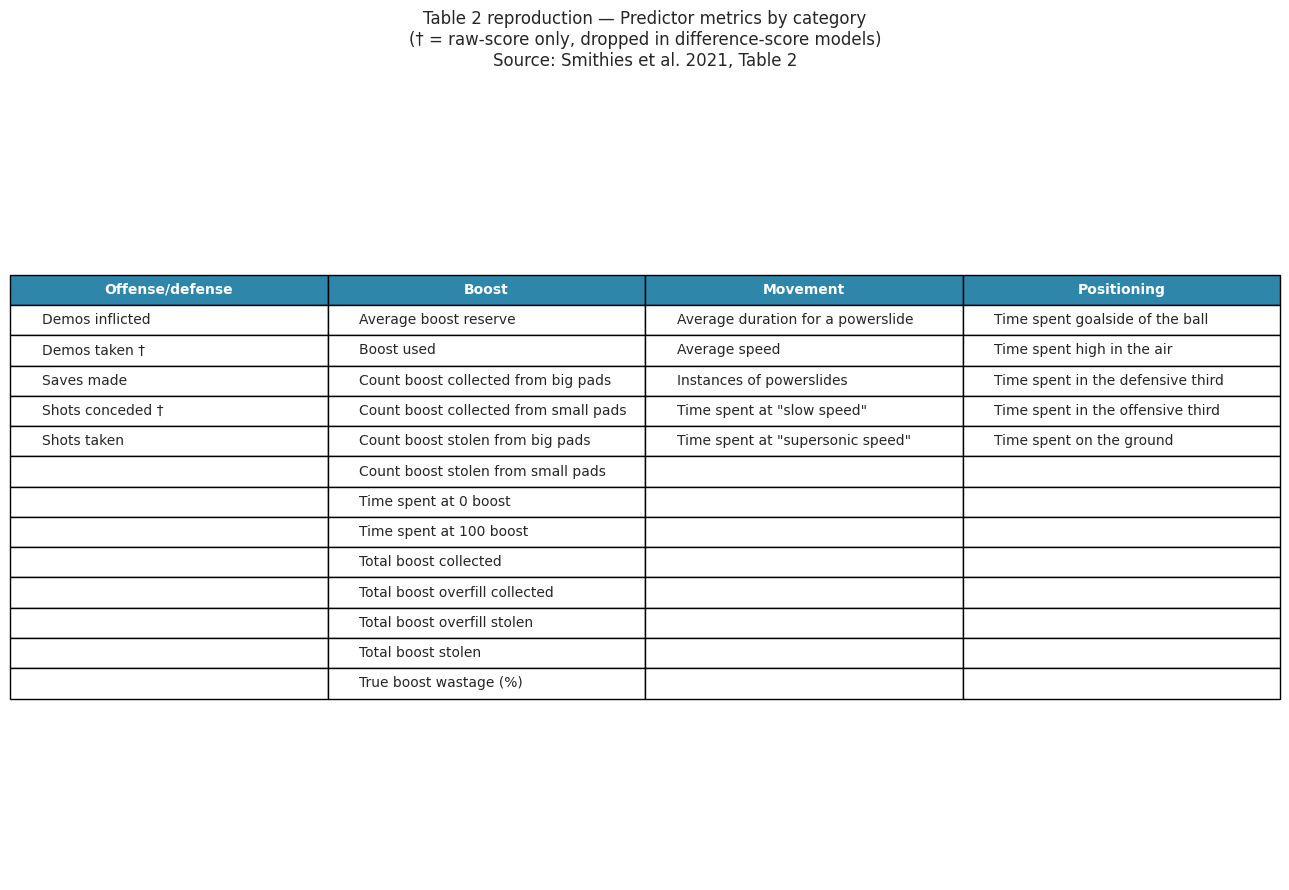

In [18]:
# Render Table 2 as a publication-style figure.
fig, ax = plt.subplots(figsize=(13, 9)); ax.axis('off')
cats = ['Offense/defense', 'Boost', 'Movement', 'Positioning']
max_rows = max(len(table2[table2['category'] == c]) for c in cats)
cell_text = []
for i in range(max_rows):
    row = []
    for cat in cats:
        sub = table2[table2['category'] == cat].reset_index(drop=True)
        if i < len(sub):
            lab = sub.loc[i, 'paper_label']
            if sub.loc[i, 'raw_only'] == 'Yes':
                lab += ' †'
        else:
            lab = ''
        row.append(lab)
    cell_text.append(row)
tbl = ax.table(cellText=cell_text, colLabels=cats, loc='center', cellLoc='left')
tbl.auto_set_font_size(False); tbl.set_fontsize(10); tbl.scale(1.0, 1.6)
for j in range(len(cats)):
    tbl[(0, j)].set_facecolor('#2E86AB')
    tbl[(0, j)].set_text_props(color='white', weight='bold')
ax.set_title('Table 2 reproduction — Predictor metrics by category\n'
             '(† = raw-score only, dropped in difference-score models)\n'
             'Source: Smithies et al. 2021, Table 2', fontsize=12, pad=20)
save_figure('table2_predictor_categories.png'); plt.show()


## 12. Figure 6 — methods flowchart
**Status: FULL.**  Fig. 6 of the paper is a flowchart of the methods, with the three analyses (1-Outcome measure, 2-PIs, 3-RIs) highlighted in blue. We rebuild it with `matplotlib.patches.FancyBboxPatch` + arrow annotations — no Graphviz / external binary dependency, so the figure renders with the same packages already used by every other analyst figure. The dagger note ("† Average speed was dropped from the GC model due to multicollinearity") is preserved verbatim from the paper.

  saved: fig6_methods_flowchart.png


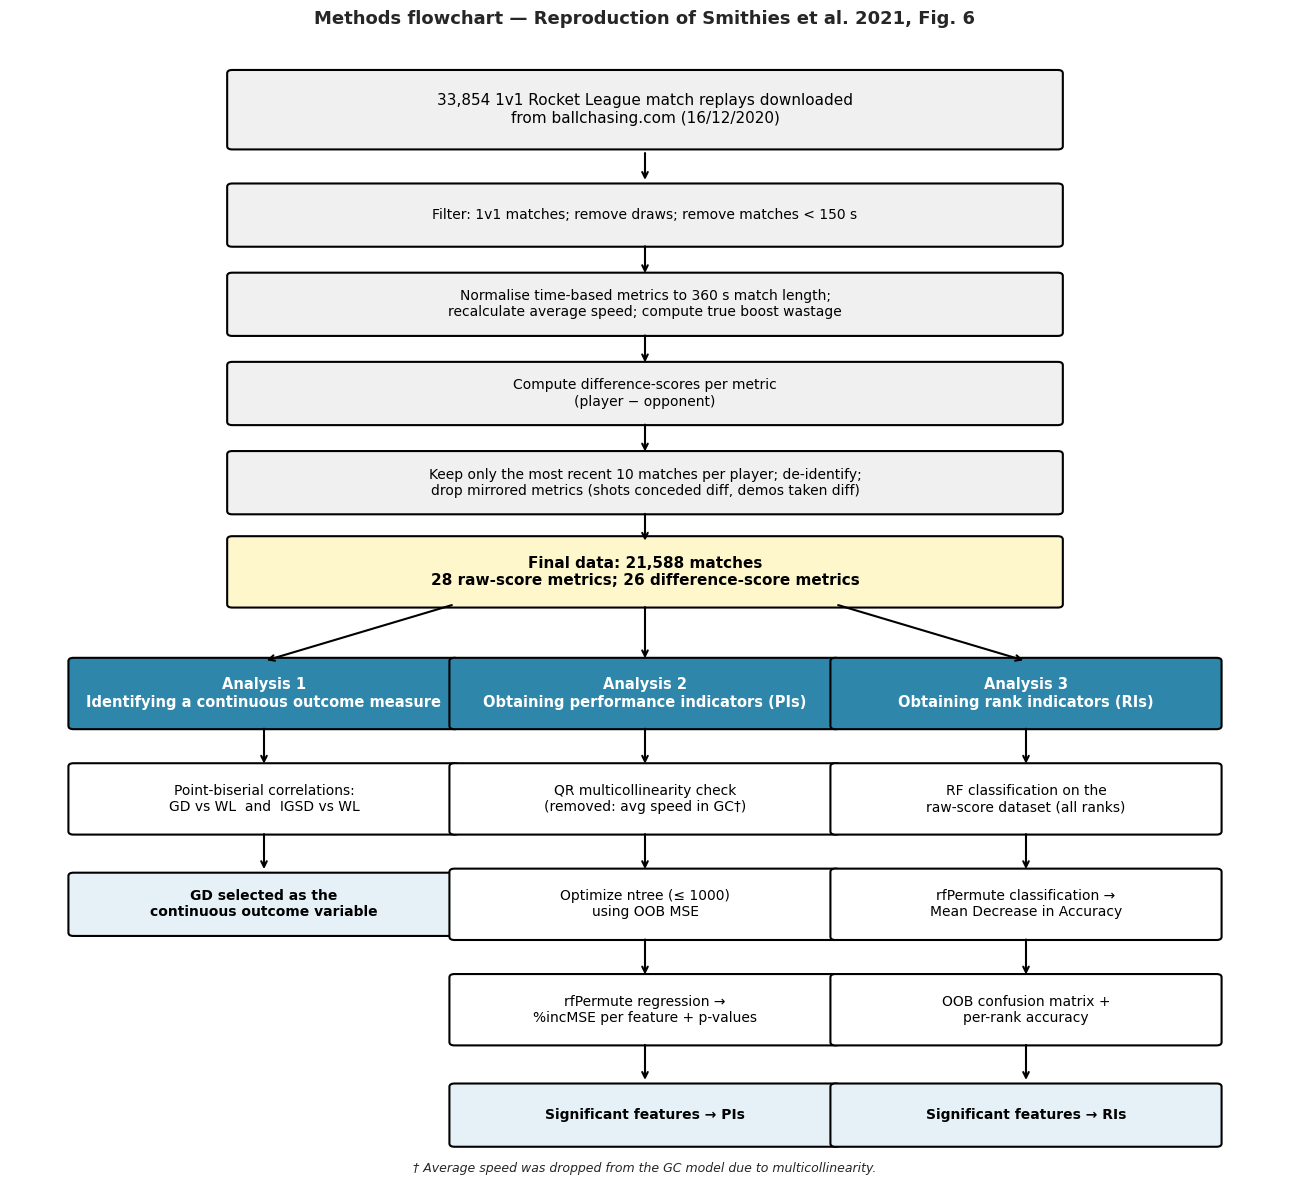

In [19]:
import matplotlib.patches as mpatches

def draw_box(ax, x, y, w, h, text, fc='#FFFFFF', ec='black',
             fontsize=10, fontweight='normal', fontcolor='black'):
    box = mpatches.FancyBboxPatch((x - w/2, y - h/2), w, h,
        boxstyle='round,pad=0.04', linewidth=1.5,
        edgecolor=ec, facecolor=fc)
    ax.add_patch(box)
    ax.text(x, y, text, ha='center', va='center',
            fontsize=fontsize, fontweight=fontweight, color=fontcolor)

def draw_arrow(ax, x1, y1, x2, y2):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', lw=1.5, color='black'))

fig, ax = plt.subplots(figsize=(13, 12))
ax.set_xlim(0, 10); ax.set_ylim(0, 14); ax.axis('off')

# Top: data source + processing
draw_box(ax, 5, 13.2, 6.5, 0.9,
         '33,854 1v1 Rocket League match replays downloaded\n'
         'from ballchasing.com (16/12/2020)', fc='#F0F0F0', fontsize=11)
draw_arrow(ax, 5, 12.7, 5, 12.3)
draw_box(ax, 5, 11.9, 6.5, 0.7,
         'Filter: 1v1 matches; remove draws; remove matches < 150 s',
         fc='#F0F0F0', fontsize=10)
draw_arrow(ax, 5, 11.55, 5, 11.15)
draw_box(ax, 5, 10.8, 6.5, 0.7,
         'Normalise time-based metrics to 360 s match length;\n'
         'recalculate average speed; compute true boost wastage',
         fc='#F0F0F0', fontsize=10)
draw_arrow(ax, 5, 10.45, 5, 10.05)
draw_box(ax, 5, 9.7, 6.5, 0.7,
         'Compute difference-scores per metric\n(player − opponent)',
         fc='#F0F0F0', fontsize=10)
draw_arrow(ax, 5, 9.35, 5, 8.95)
draw_box(ax, 5, 8.6, 6.5, 0.7,
         'Keep only the most recent 10 matches per player; de-identify;\n'
         'drop mirrored metrics (shots conceded diff, demos taken diff)',
         fc='#F0F0F0', fontsize=10)
draw_arrow(ax, 5, 8.25, 5, 7.85)
draw_box(ax, 5, 7.5, 6.5, 0.8,
         'Final data: 21,588 matches\n'
         '28 raw-score metrics; 26 difference-score metrics',
         fc='#FFF7CC', fontsize=11, fontweight='bold')

# Split into three analyses
draw_arrow(ax, 3.5, 7.1, 2.0, 6.4)
draw_arrow(ax, 5.0, 7.1, 5.0, 6.4)
draw_arrow(ax, 6.5, 7.1, 8.0, 6.4)

draw_box(ax, 2.0, 6.0, 3.0, 0.8,
         'Analysis 1\nIdentifying a continuous outcome measure',
         fc='#2E86AB', fontsize=10.5, fontweight='bold', fontcolor='white')
draw_arrow(ax, 2.0, 5.6, 2.0, 5.1)
draw_box(ax, 2.0, 4.7, 3.0, 0.8,
         'Point-biserial correlations:\nGD vs WL  and  IGSD vs WL',
         fc='#FFFFFF', fontsize=10)
draw_arrow(ax, 2.0, 4.3, 2.0, 3.8)
draw_box(ax, 2.0, 3.4, 3.0, 0.7,
         'GD selected as the\ncontinuous outcome variable',
         fc='#E5F1F7', fontsize=10, fontweight='bold')

draw_box(ax, 5.0, 6.0, 3.0, 0.8,
         'Analysis 2\nObtaining performance indicators (PIs)',
         fc='#2E86AB', fontsize=10.5, fontweight='bold', fontcolor='white')
draw_arrow(ax, 5.0, 5.6, 5.0, 5.1)
draw_box(ax, 5.0, 4.7, 3.0, 0.8,
         'QR multicollinearity check\n(removed: avg speed in GC†)',
         fc='#FFFFFF', fontsize=10)
draw_arrow(ax, 5.0, 4.3, 5.0, 3.8)
draw_box(ax, 5.0, 3.4, 3.0, 0.8,
         'Optimize ntree (≤ 1000)\nusing OOB MSE',
         fc='#FFFFFF', fontsize=10)
draw_arrow(ax, 5.0, 3.0, 5.0, 2.5)
draw_box(ax, 5.0, 2.1, 3.0, 0.8,
         'rfPermute regression →\n%incMSE per feature + p-values',
         fc='#FFFFFF', fontsize=10)
draw_arrow(ax, 5.0, 1.7, 5.0, 1.2)
draw_box(ax, 5.0, 0.8, 3.0, 0.7,
         'Significant features → PIs',
         fc='#E5F1F7', fontsize=10, fontweight='bold')

draw_box(ax, 8.0, 6.0, 3.0, 0.8,
         'Analysis 3\nObtaining rank indicators (RIs)',
         fc='#2E86AB', fontsize=10.5, fontweight='bold', fontcolor='white')
draw_arrow(ax, 8.0, 5.6, 8.0, 5.1)
draw_box(ax, 8.0, 4.7, 3.0, 0.8,
         'RF classification on the\nraw-score dataset (all ranks)',
         fc='#FFFFFF', fontsize=10)
draw_arrow(ax, 8.0, 4.3, 8.0, 3.8)
draw_box(ax, 8.0, 3.4, 3.0, 0.8,
         'rfPermute classification →\nMean Decrease in Accuracy',
         fc='#FFFFFF', fontsize=10)
draw_arrow(ax, 8.0, 3.0, 8.0, 2.5)
draw_box(ax, 8.0, 2.1, 3.0, 0.8,
         'OOB confusion matrix +\nper-rank accuracy',
         fc='#FFFFFF', fontsize=10)
draw_arrow(ax, 8.0, 1.7, 8.0, 1.2)
draw_box(ax, 8.0, 0.8, 3.0, 0.7,
         'Significant features → RIs',
         fc='#E5F1F7', fontsize=10, fontweight='bold')

ax.text(5, 0.1,
        '† Average speed was dropped from the GC model due to multicollinearity.',
        ha='center', fontsize=9, style='italic')
ax.set_title('Methods flowchart — Reproduction of Smithies et al. 2021, Fig. 6',
             fontsize=13, fontweight='bold', pad=15)
save_figure('fig6_methods_flowchart.png'); plt.show()


## 10. Where each artefact lives
* All figures: `analyst_figures/*.png`
* All tables (CSV): `analyst_figures/*.csv`
* Reproducibility notes & diffs from the paper: `update.txt`
